##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install tensorflow tensorflow-text keras-hub pillow requests numpy

Mounted at /content/drive


In [2]:
import os
folder = "/content/drive/MyDrive/ARTI560"
print("Files in folder:", folder)
print("\n".join(os.listdir(folder)))

Files in folder: /content/drive/MyDrive/ARTI560
goldenre.jpg
banana.jpg
elephant.jpg
firetruck.jpg
coffe.jpg


In [8]:
import numpy as np
import requests
from PIL import Image
import tensorflow as tf
import keras_hub

PRESET = "vit_base_patch16_224_imagenet"  # listed in KerasHub presets :contentReference[oaicite:1]{index=1}

preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(PRESET)

model = keras_hub.models.ViTImageClassifier.from_preset(PRESET, preprocessor=None)

# Load ImageNet-1K labels
classnames_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(classnames_url, timeout=30).text.strip().splitlines()

SAMPLES = [
    ("banana", "/content/drive/MyDrive/ARTI560/banana.jpg"),
    ("cup", "/content/drive/MyDrive/ARTI560/coffe.jpg"),
    ("fire engine", "/content/drive/MyDrive/ARTI560/firetruck.jpg"),
    ("golden retriever", "/content/drive/MyDrive/ARTI560/goldenre.jpg"),
    ("African elephant", "/content/drive/MyDrive/ARTI560/elephant.jpg"),
]

print("\n----- ViT Predictions -----\n")

for true_label, path in SAMPLES:
    img = Image.open(path).convert("RGB")

    x = preprocessor(img)
    if isinstance(x, dict):
        x = x.get("images", x)

    x = tf.convert_to_tensor(x)
    if len(x.shape) == 3:
        x = tf.expand_dims(x, 0)

    logits = model.predict(x, verbose=0)
    pred_idx = int(np.argmax(logits, axis=-1)[0])
    pred_label = imagenet_classes[pred_idx]

    correct = true_label.lower() in pred_label.lower()

    print("File:", path.split("/")[-1])
    print("True label:", true_label)
    print("Predicted:", pred_label)
    print("Correct:", correct)
    print("---------------------------------\n")


----- ViT Predictions -----

File: banana.jpg
True label: banana
Predicted: banana
Correct: True
---------------------------------

File: coffe.jpg
True label: cup
Predicted: cup
Correct: True
---------------------------------

File: firetruck.jpg
True label: fire engine
Predicted: fire engine
Correct: True
---------------------------------

File: goldenre.jpg
True label: golden retriever
Predicted: golden retriever
Correct: True
---------------------------------

File: elephant.jpg
True label: African elephant
Predicted: African elephant
Correct: True
---------------------------------



100%|██████████| 1.65k/1.65k [00:00<00:00, 3.83MB/s]


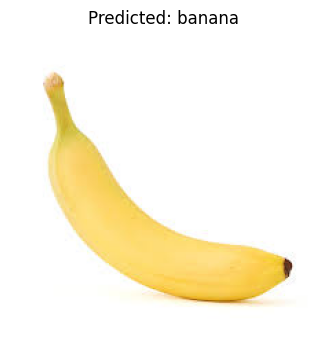

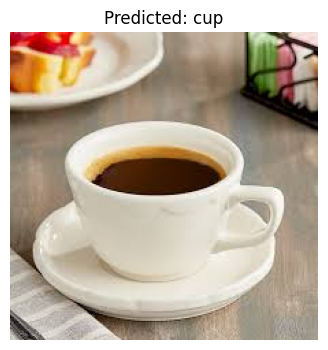

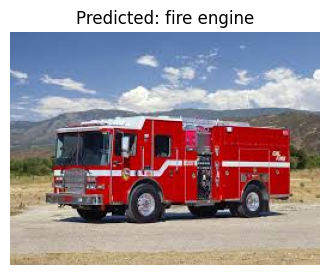

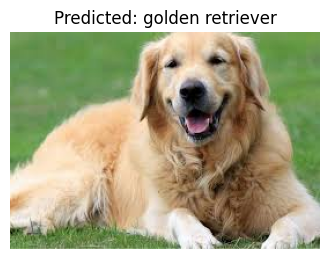

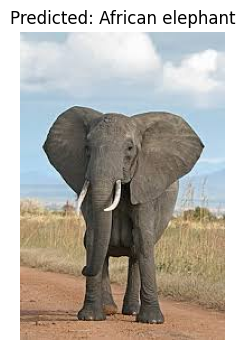

In [9]:
import numpy as np
import requests
from PIL import Image
import tensorflow as tf
import keras_hub
import matplotlib.pyplot as plt

# Your images
SAMPLES = [
    ("banana", "/content/drive/MyDrive/ARTI560/banana.jpg"),
    ("cup", "/content/drive/MyDrive/ARTI560/coffe.jpg"),
    ("fire engine", "/content/drive/MyDrive/ARTI560/firetruck.jpg"),
    ("golden retriever", "/content/drive/MyDrive/ARTI560/goldenre.jpg"),
    ("African elephant", "/content/drive/MyDrive/ARTI560/elephant.jpg"),
]

# Load ImageNet class names
classnames_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(classnames_url).text.strip().splitlines()

# Load model
PRESET = "vit_base_patch16_224_imagenet"
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(PRESET)
model = keras_hub.models.ViTImageClassifier.from_preset(PRESET, preprocessor=None)

for true_label, path in SAMPLES:

    img = Image.open(path).convert("RGB")

    # preprocess image
    x = preprocessor(img)
    if isinstance(x, dict):
        x = x["images"]

    x = tf.expand_dims(x, 0)

    # prediction
    preds = model.predict(x, verbose=0)
    pred_index = np.argmax(preds)
    pred_label = imagenet_classes[pred_index]

    # show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {pred_label}")
    plt.show()

### Record Your Results

| Image File    | Predicted Label  | True Label       | Correct |
| ------------- | ---------------- | ---------------- | ------- |
| banana.jpg    | banana           | banana           | Yes     |
| coffe.jpg     | cup              | espresso         | Yes     |
| firetruck.jpg | fire engine      | fire engine      | Yes     |
| goldenre.jpg  | golden retriever | golden retriever | Yes     |
| elephant.jpg  | African elephant | African elephant | Yes     |

